### 통계 검정 및 상관관계 분석

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import (
    mannwhitneyu, kruskal, pointbiserialr, spearmanr
)
from itertools import combinations
import platform

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

# ============================================================
# 공통 색상 팔레트
# ============================================================
BATTERY_COLORS = {
    'B0005': '#1565C0',
    'B0006': '#2196F3',
    'B0007': '#64B5F6',
    'B0018': '#90CAF9',
}
STAGE_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E53935']

def rank_biserial(x, y):
    u, _ = mannwhitneyu(x, y, alternative='two-sided')
    return 1 - (2 * u) / (len(x) * len(y))

def bonferroni_p(p_values):
    n = len(p_values)
    return [min(p * n, 1.0) for p in p_values]

print("=" * 60)
print("라이브러리 로드 완료")
print("=" * 60)


라이브러리 로드 완료


In [2]:
# ============================================================
# 데이터 로드 (실제 컬럼명 기준)
# ============================================================
base_path = 'data/new_data'

df_A     = pd.read_csv(os.path.join(base_path, 'df_A_main.csv'))
df_imp_A = pd.read_csv(os.path.join(base_path, 'df_imp_A_main.csv'))

# start_time 변환
df_A['start_time']     = pd.to_datetime(df_A['start_time'],     errors='coerce')
df_imp_A['start_time'] = pd.to_datetime(df_imp_A['start_time'], errors='coerce')

# imp_cycle_no 컬럼명 통일 (실제 파일은 impedance_cycle_no)
if 'imp_cycle_no' not in df_imp_A.columns:
    if 'impedance_cycle_no' in df_imp_A.columns:
        df_imp_A['imp_cycle_no'] = df_imp_A['impedance_cycle_no']
    else:
        df_imp_A = df_imp_A.sort_values(['battery_id', 'test_id'])
        df_imp_A['imp_cycle_no'] = df_imp_A.groupby('battery_id').cumcount() + 1

# valid 행 필터
df_A_valid = df_A[df_A['cap_flag'] == 'valid'].copy()
df_A_valid = df_A_valid.dropna(subset=['start_time'])
df_A_valid = df_A_valid.sort_values(['battery_id', 'discharge_cycle_raw'])

# SOH_diff 계산
df_A_valid['SOH_diff'] = df_A_valid.groupby('battery_id')['SOH_relative'].diff()

# impedance merge_asof → Re_mean, Rct_mean 생성
df_imp_A['Re']  = pd.to_numeric(df_imp_A['Re'],  errors='coerce')
df_imp_A['Rct'] = pd.to_numeric(df_imp_A['Rct'], errors='coerce')
df_imp_A = df_imp_A.sort_values(['battery_id', 'start_time']).reset_index(drop=True)
df_imp_A['Re_cumean']  = df_imp_A.groupby('battery_id')['Re'].expanding().mean().reset_index(level=0, drop=True)
df_imp_A['Rct_cumean'] = df_imp_A.groupby('battery_id')['Rct'].expanding().mean().reset_index(level=0, drop=True)

results = []
for bid in df_A_valid['battery_id'].unique():
    d = df_A_valid[df_A_valid['battery_id'] == bid].sort_values('start_time').reset_index(drop=True)
    i = df_imp_A[df_imp_A['battery_id'] == bid][['start_time', 'Re_cumean', 'Rct_cumean']].sort_values('start_time').reset_index(drop=True)
    merged = pd.merge_asof(d, i, on='start_time', direction='backward')
    results.append(merged)

df_A_valid = pd.concat(results, ignore_index=True)
df_A_valid = df_A_valid.rename(columns={'Re_cumean': 'Re_mean', 'Rct_cumean': 'Rct_mean'})
df_A_valid = df_A_valid.sort_values(['battery_id', 'discharge_cycle_raw'])
df_A_valid['Re_mean']  = df_A_valid.groupby('battery_id')['Re_mean'].ffill()
df_A_valid['Rct_mean'] = df_A_valid.groupby('battery_id')['Rct_mean'].ffill()

# RUL 계산
eol_A = (df_A_valid[df_A_valid['SOH_nominal'] < 70]
         .groupby('battery_id')['discharge_cycle_raw']
         .min().rename('eol'))
df_A_valid = df_A_valid.merge(eol_A, on='battery_id', how='left')
df_A_valid['RUL'] = (df_A_valid['eol'] - df_A_valid['discharge_cycle_raw']).clip(lower=0)

# ML 데이터셋 (stat_re_rul_correlation용 — Re_mean/RUL 보장)
df_rul_ml = pd.read_csv(os.path.join(base_path, 'df_ml_dataset.csv'))
df_rul_ml = df_rul_ml.dropna(subset=['Re_mean', 'RUL'])
if 'Rct_mean' not in df_rul_ml.columns and 'Rct_last' in df_rul_ml.columns:
    df_rul_ml['Rct_mean'] = df_rul_ml['Rct_last']

batteries = sorted(df_A_valid['battery_id'].unique())

print("=" * 60)
print("데이터 로드 완료")
print("=" * 60)
print(f"df_A_valid : {len(df_A_valid)}행  배터리={batteries}")
print(f"df_rul_ml  : {len(df_rul_ml)}행")


데이터 로드 완료
df_A_valid : 636행  배터리=['B0005', 'B0006', 'B0007', 'B0018']
df_rul_ml  : 430행


[기술통계]
  B0005: 평균=0.4438%/사이클  중앙값=0.2900  n=167
  B0006: 평균=0.7128%/사이클  중앙값=0.5200  n=167
  B0007: 평균=0.3695%/사이클  중앙값=0.2700  n=167
  B0018: 평균=0.7692%/사이클  중앙값=0.5400  n=131

Kruskal-Wallis: H=59.7966, p=0.0000
→ 집단 간 유의미한 차이 있음

pairwise Mann-Whitney (Bonferroni 보정)
쌍                           U     p(raw)      p(보정)      RBC     유의
-----------------------------------------------------------------
B0005 vs B0006       11309.0     0.0028     0.0169    0.189    sig
B0005 vs B0007       16160.0     0.0120     0.0721   -0.159       
B0005 vs B0018        7005.0     0.0000     0.0000    0.360    sig
B0006 vs B0007       18545.0     0.0000     0.0000   -0.330    sig
B0006 vs B0018       10128.0     0.2725     1.0000    0.074       
B0007 vs B0018        5696.0     0.0000     0.0000    0.479    sig


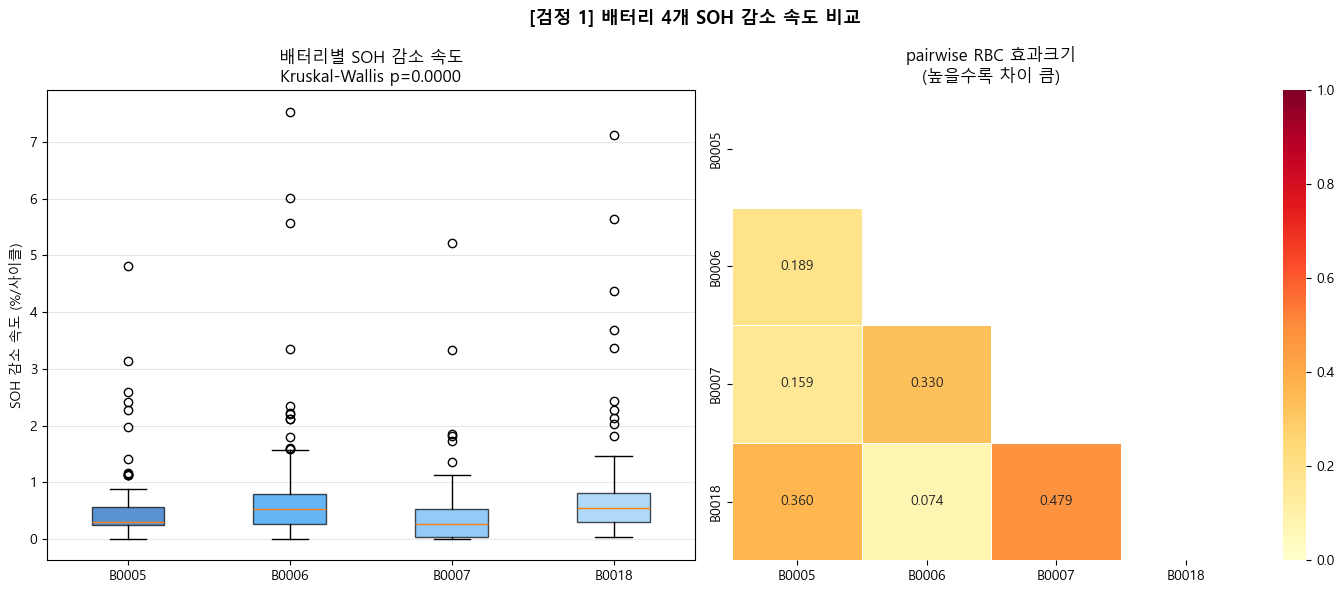

[저장] stat_kruskal_soh_speed.png


In [3]:
# ============================================================
# 검정 1. Kruskal-Wallis + pairwise Mann-Whitney + RBC
# 배터리 4개 SOH 감소 속도 비교
# ============================================================
groups = {
    bid: df_A_valid[df_A_valid['battery_id'] == bid]['SOH_diff'].dropna().abs().values
    for bid in batteries
}

print("[기술통계]")
for bid, vals in groups.items():
    print(f"  {bid}: 평균={vals.mean():.4f}%/사이클  중앙값={np.median(vals):.4f}  n={len(vals)}")

stat, p = kruskal(*groups.values())
print(f"\nKruskal-Wallis: H={stat:.4f}, p={p:.4f}")
print(f"→ {'집단 간 유의미한 차이 있음' if p < 0.05 else '차이 없음'}")

pairs = list(combinations(batteries, 2))
raw_ps, pair_stats = [], []
for b1, b2 in pairs:
    u, p_raw = mannwhitneyu(groups[b1], groups[b2], alternative='two-sided')
    rbc = rank_biserial(groups[b1], groups[b2])
    raw_ps.append(p_raw)
    pair_stats.append((b1, b2, u, p_raw, rbc))

bonf_ps = bonferroni_p(raw_ps)
print(f"\npairwise Mann-Whitney (Bonferroni 보정)")
print(f"{'쌍':<20} {'U':>8} {'p(raw)':>10} {'p(보정)':>10} {'RBC':>8} {'유의':>6}")
print("-" * 65)
for i, (b1, b2, u, p_raw, rbc) in enumerate(pair_stats):
    p_adj = bonf_ps[i]
    sig = 'sig' if p_adj < 0.05 else ''
    print(f"{b1} vs {b2:<10} {u:>8.1f} {p_raw:>10.4f} {p_adj:>10.4f} {rbc:>8.3f} {sig:>6}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

data_list = [groups[b] for b in batteries]
bp = axes[0].boxplot(data_list, labels=batteries, patch_artist=True)
for patch, bid in zip(bp['boxes'], batteries):
    patch.set_facecolor(BATTERY_COLORS.get(bid, '#90A4AE'))
    patch.set_alpha(0.7)
axes[0].set_ylabel('SOH 감소 속도 (%/사이클)')
axes[0].set_title(f'배터리별 SOH 감소 속도\nKruskal-Wallis p={p:.4f}')
axes[0].grid(axis='y', alpha=0.3)

rbc_matrix = pd.DataFrame(np.zeros((len(batteries), len(batteries))),
                           index=batteries, columns=batteries)
for b1, b2, u, p_raw, rbc in pair_stats:
    rbc_matrix.loc[b1, b2] = abs(rbc)
    rbc_matrix.loc[b2, b1] = abs(rbc)
mask = np.triu(np.ones_like(rbc_matrix, dtype=bool))
sns.heatmap(rbc_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1], mask=mask, vmin=0, vmax=1, linewidths=0.5)
axes[1].set_title('pairwise RBC 효과크기\n(높을수록 차이 큼)')

plt.suptitle('[검정 1] 배터리 4개 SOH 감소 속도 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_kruskal_soh_speed.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_kruskal_soh_speed.png')


[구간별 Re 기술통계]
  r_90이상: 평균=0.0507Ω  중앙값=0.0466  n=154
  v_80-90: 평균=0.0529Ω  중앙값=0.0490  n=156
  e_70-80: 평균=0.0578Ω  중앙값=0.0542  n=208
  c_70미만: 평균=0.0687Ω  중앙값=0.0688  n=61

[인접 구간 Mann-Whitney (단조성 확인)]
  r_90이상 < v_80-90: p=0.0000  RBC=0.309  [sig]
  v_80-90 < e_70-80: p=0.0000  RBC=0.572  [sig]
  e_70-80 < c_70미만: p=0.0000  RBC=1.000  [sig]

Kruskal-Wallis (전체): H=267.6573, p=0.0000
단조 증가 패턴: 확인됨


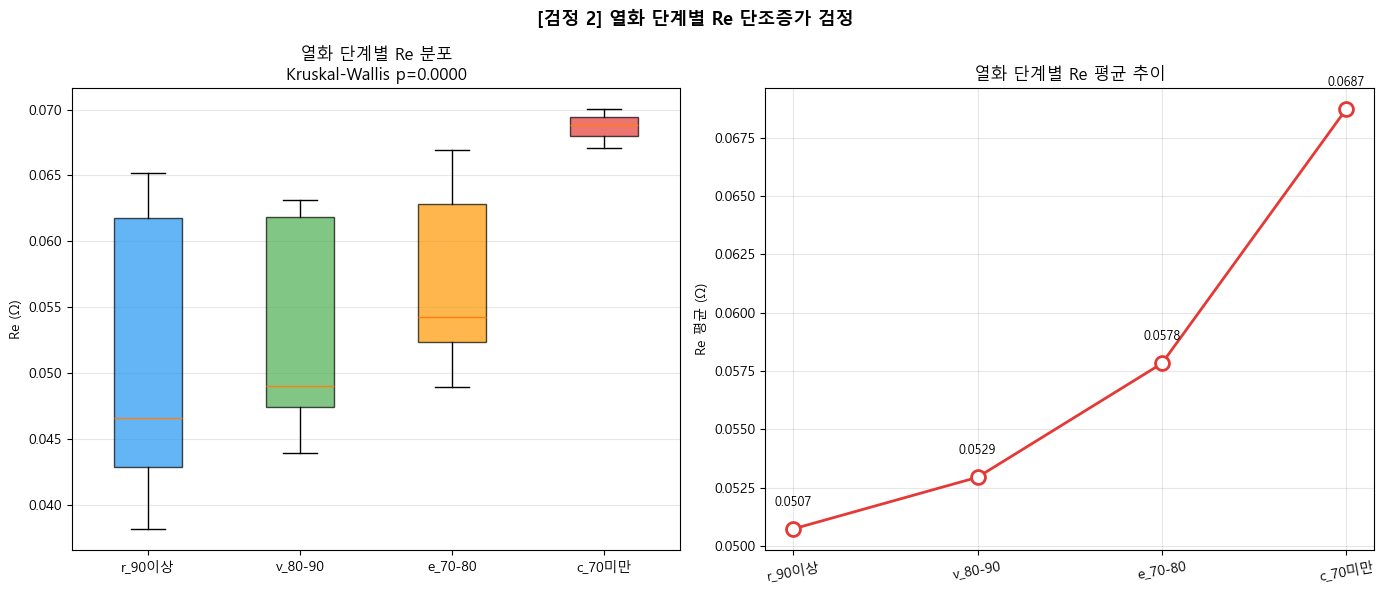

[저장] stat_jonckheere_re_stage.png


In [4]:
# ============================================================
# 검정 2. Jonckheere-Terpstra (열화 단계별 Re 단조증가)
# ============================================================
df_A_valid['soh_stage'] = pd.cut(
    df_A_valid['SOH_relative'],
    bins=[0, 70, 80, 90, 110],
    labels=['c_70미만', 'e_70-80', 'v_80-90', 'r_90이상']
)

stage_order = ['r_90이상', 'v_80-90', 'e_70-80', 'c_70미만']
stage_data  = {
    s: df_A_valid[df_A_valid['soh_stage'] == s]['Re_mean'].dropna().values
    for s in stage_order
}

print("[구간별 Re 기술통계]")
for s in stage_order:
    vals = stage_data[s]
    if len(vals) > 0:
        print(f"  {s}: 평균={vals.mean():.4f}Ω  중앙값={np.median(vals):.4f}  n={len(vals)}")

print("\n[인접 구간 Mann-Whitney (단조성 확인)]")
all_sig = True
adjacent = [('r_90이상','v_80-90'), ('v_80-90','e_70-80'), ('e_70-80','c_70미만')]
for s1, s2 in adjacent:
    d1, d2 = stage_data[s1], stage_data[s2]
    if len(d1) > 0 and len(d2) > 0:
        u, p_mw = mannwhitneyu(d1, d2, alternative='less')
        rbc = rank_biserial(d1, d2)
        sig = 'sig' if p_mw < 0.05 else 'not sig'
        print(f"  {s1} < {s2}: p={p_mw:.4f}  RBC={rbc:.3f}  [{sig}]")
        if p_mw >= 0.05:
            all_sig = False

valid_stages = [stage_data[s] for s in stage_order if len(stage_data[s]) > 0]
stat_kw, p_kw = kruskal(*valid_stages)
print(f"\nKruskal-Wallis (전체): H={stat_kw:.4f}, p={p_kw:.4f}")
print(f"단조 증가 패턴: {'확인됨' if all_sig else '일부 구간 불확실'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

data_plot   = [stage_data[s] for s in stage_order if len(stage_data[s]) > 0]
labels_plot = [s for s in stage_order if len(stage_data[s]) > 0]
bp = axes[0].boxplot(data_plot, labels=labels_plot, patch_artist=True)
for patch, color in zip(bp['boxes'], STAGE_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Re (Ω)')
axes[0].set_title(f'열화 단계별 Re 분포\nKruskal-Wallis p={p_kw:.4f}')
axes[0].grid(axis='y', alpha=0.3)

means = [np.mean(stage_data[s]) for s in stage_order if len(stage_data[s]) > 0]
axes[1].plot(range(len(means)), means, 'o-', color='#E53935',
             linewidth=2, markersize=10, markerfacecolor='white', markeredgewidth=2)
for i, (m, l) in enumerate(zip(means, labels_plot)):
    axes[1].text(i, m + 0.001, f'{m:.4f}', ha='center', fontsize=9)
axes[1].set_xticks(range(len(labels_plot)))
axes[1].set_xticklabels(labels_plot, rotation=10)
axes[1].set_ylabel('Re 평균 (Ω)')
axes[1].set_title('열화 단계별 Re 평균 추이')
axes[1].grid(alpha=0.3)

plt.suptitle('[검정 2] 열화 단계별 Re 단조증가 검정', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_jonckheere_re_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_jonckheere_re_stage.png')


Point-Biserial r=0.6674, p=0.0000
→ B0006이 Re 유의미하게 높음

배터리별 초기 Re:
  B0005: 0.0452 Ω
  B0006: 0.0617 Ω <-- B0006
  B0007: 0.0395 Ω
  B0018: 0.0629 Ω


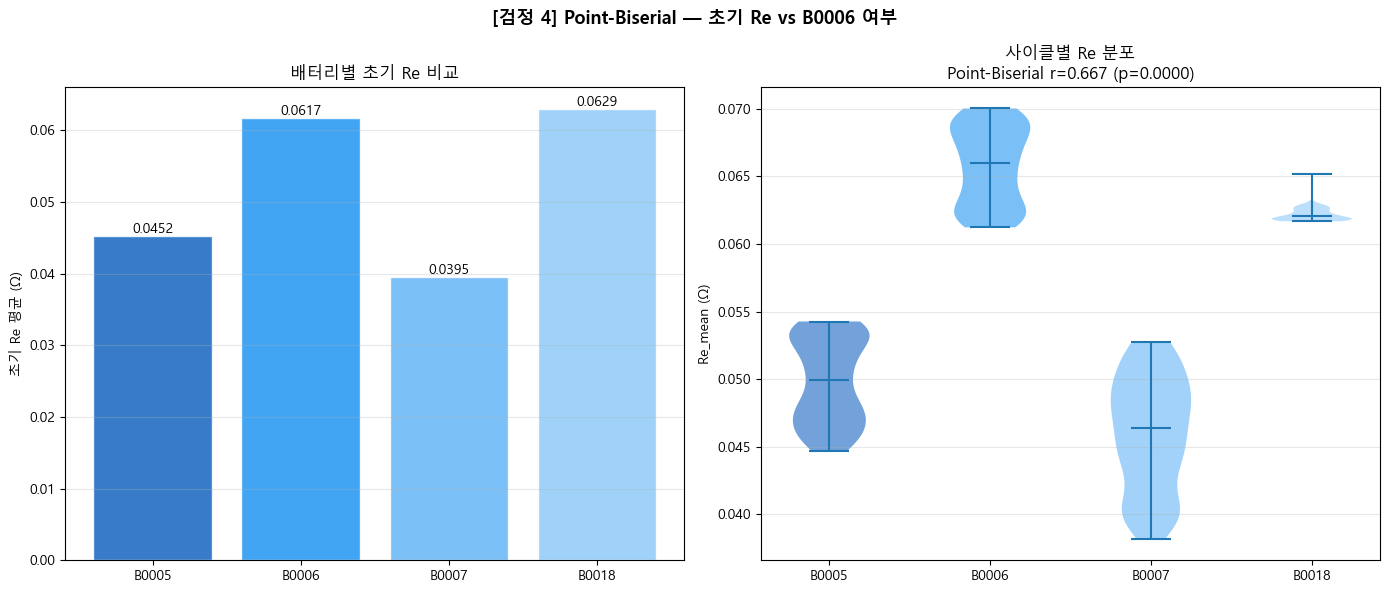

[저장] stat_pointbiserial_re.png


In [5]:
# ============================================================
# 검정 4. Point-Biserial 상관
# 초기 Re vs B0006 여부 (이진변수)
# ============================================================
init_re = {}
for bid in batteries:
    b = df_A_valid[df_A_valid['battery_id'] == bid]['Re_mean'].dropna().head(10)
    init_re[bid] = b.mean()

rows = []
for bid in batteries:
    b = df_A_valid[df_A_valid['battery_id'] == bid].dropna(subset=['Re_mean'])
    for _, row in b.iterrows():
        rows.append({'battery_id': bid,
                     'is_b0006': 1 if bid == 'B0006' else 0,
                     're_mean': row['Re_mean']})
pb_df = pd.DataFrame(rows)

r_cycle, p_cycle = pointbiserialr(pb_df['is_b0006'], pb_df['re_mean'])
print(f"Point-Biserial r={r_cycle:.4f}, p={p_cycle:.4f}")
print(f"→ {'B0006이 Re 유의미하게 높음' if p_cycle < 0.05 else '유의미하지 않음'}")

print("\n배터리별 초기 Re:")
for bid in batteries:
    marker = ' <-- B0006' if bid == 'B0006' else ''
    print(f"  {bid}: {init_re[bid]:.4f} Ω{marker}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bar_colors = [BATTERY_COLORS.get(b, '#90A4AE') for b in batteries]
bars = axes[0].bar(batteries, [init_re[b] for b in batteries],
                   color=bar_colors, alpha=0.85, edgecolor='white')
for bar, bid in zip(bars, batteries):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{init_re[bid]:.4f}', ha='center', fontsize=10)
axes[0].set_ylabel('초기 Re 평균 (Ω)')
axes[0].set_title('배터리별 초기 Re 비교')
axes[0].grid(axis='y', alpha=0.3)

parts = axes[1].violinplot(
    [pb_df[pb_df['battery_id'] == bid]['re_mean'].values for bid in batteries],
    positions=range(len(batteries)), showmedians=True
)
for pc, bid in zip(parts['bodies'], batteries):
    pc.set_facecolor(BATTERY_COLORS.get(bid, '#90A4AE'))
    pc.set_alpha(0.6)
axes[1].set_xticks(range(len(batteries)))
axes[1].set_xticklabels(batteries)
axes[1].set_ylabel('Re_mean (Ω)')
axes[1].set_title(f'사이클별 Re 분포\nPoint-Biserial r={r_cycle:.3f} (p={p_cycle:.4f})')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('[검정 4] Point-Biserial — 초기 Re vs B0006 여부', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_pointbiserial_re.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_pointbiserial_re.png')


Re·Rct·SOH vs RUL 상관계수
Re-RUL:  r=-0.4828  p=0.0000
Rct-RUL: r=-0.6420  p=0.0000
SOH-RUL: r=0.9232  p=0.0000


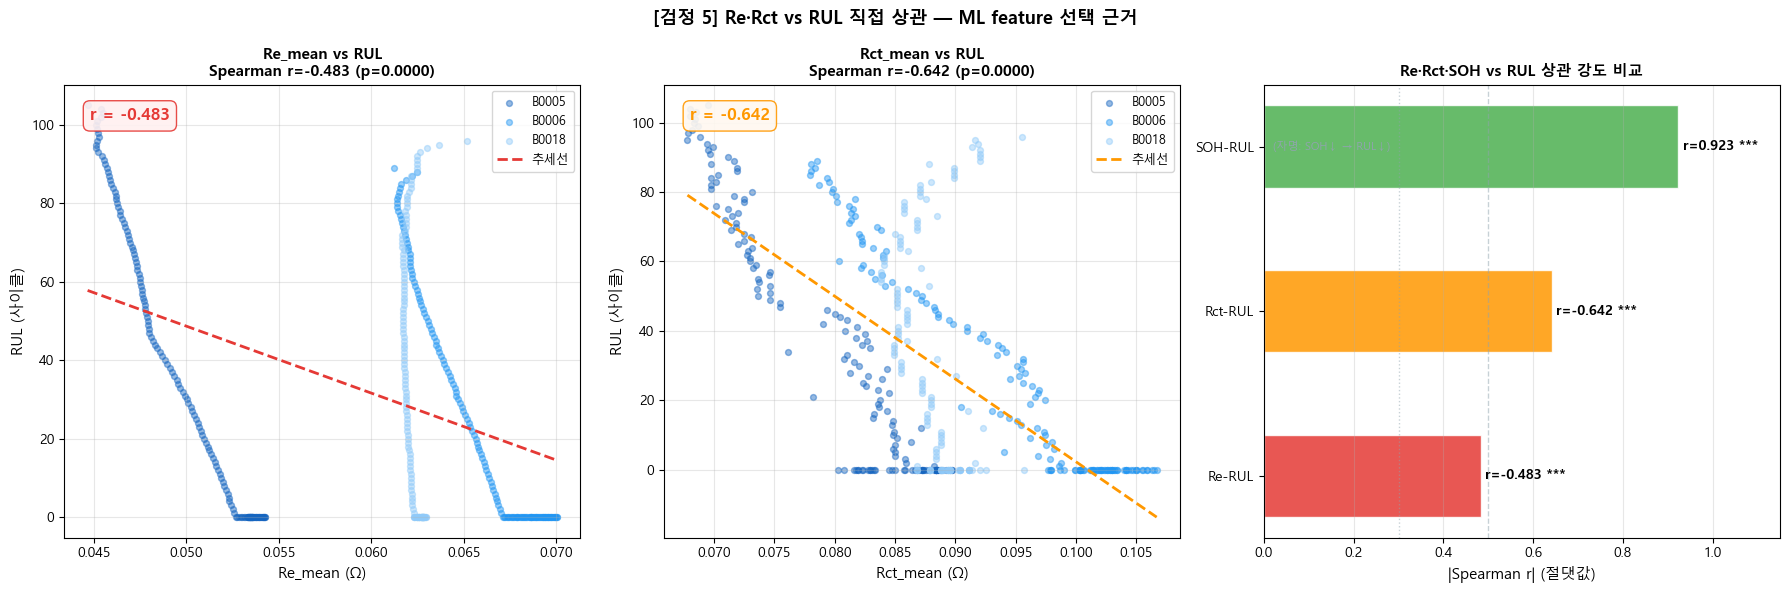

[저장] stat_re_rul_correlation.png

Re-RUL: r=-0.483  Rct-RUL: r=-0.642  SOH-RUL: r=0.923


In [6]:
# ============================================================
# 검정 5. Re·Rct·SOH vs RUL 직접 상관
# df_rul_ml = df_ml_dataset (Re_mean/RUL 컬럼 보장)
# ============================================================
r_re,  p_re  = spearmanr(df_rul_ml['Re_mean'],    df_rul_ml['RUL'])
r_soh, p_soh = spearmanr(df_rul_ml['SOH_relative'], df_rul_ml['RUL'])

# Rct_mean 또는 Rct_last 사용
rct_col = 'Rct_mean' if 'Rct_mean' in df_rul_ml.columns else 'Rct_last'
r_rct, p_rct = spearmanr(df_rul_ml[rct_col].dropna(),
                          df_rul_ml.loc[df_rul_ml[rct_col].notna(), 'RUL'])

print("=" * 55)
print("Re·Rct·SOH vs RUL 상관계수")
print("=" * 55)
print(f"Re-RUL:  r={r_re:.4f}  p={p_re:.4f}")
print(f"Rct-RUL: r={r_rct:.4f}  p={p_rct:.4f}")
print(f"SOH-RUL: r={r_soh:.4f}  p={p_soh:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ─ 왼쪽: Re vs RUL
for bid in df_rul_ml['battery_id'].unique():
    b = df_rul_ml[df_rul_ml['battery_id'] == bid]
    axes[0].scatter(b['Re_mean'], b['RUL'],
                    color=BATTERY_COLORS.get(bid, '#90A4AE'),
                    alpha=0.45, s=18, label=bid)
m, c = np.polyfit(df_rul_ml['Re_mean'], df_rul_ml['RUL'], 1)
x_line = np.linspace(df_rul_ml['Re_mean'].min(), df_rul_ml['Re_mean'].max(), 100)
axes[0].plot(x_line, m*x_line + c, color='#E53935', linewidth=2, linestyle='--', label='추세선')
axes[0].set_xlabel('Re_mean (Ω)', fontsize=11)
axes[0].set_ylabel('RUL (사이클)', fontsize=11)
axes[0].set_title(f'Re_mean vs RUL\nSpearman r={r_re:.3f} (p={p_re:.4f})', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.95, f'r = {r_re:.3f}', transform=axes[0].transAxes,
             fontsize=12, fontweight='bold', va='top', color='#E53935',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff0f0', edgecolor='#E53935', alpha=0.9))

# ─ 가운데: Rct vs RUL
rct_vals = df_rul_ml[rct_col].dropna()
rul_vals  = df_rul_ml.loc[df_rul_ml[rct_col].notna(), 'RUL']
bid_vals  = df_rul_ml.loc[df_rul_ml[rct_col].notna(), 'battery_id']
for bid in bid_vals.unique():
    mask = bid_vals == bid
    axes[1].scatter(rct_vals[mask], rul_vals[mask],
                    color=BATTERY_COLORS.get(bid, '#90A4AE'),
                    alpha=0.45, s=18, label=bid)
m2, c2 = np.polyfit(rct_vals, rul_vals, 1)
x_line2 = np.linspace(rct_vals.min(), rct_vals.max(), 100)
axes[1].plot(x_line2, m2*x_line2 + c2, color='#FF9800', linewidth=2, linestyle='--', label='추세선')
axes[1].set_xlabel(f'{rct_col} (Ω)', fontsize=11)
axes[1].set_ylabel('RUL (사이클)', fontsize=11)
axes[1].set_title(f'{rct_col} vs RUL\nSpearman r={r_rct:.3f} (p={p_rct:.4f})', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].text(0.05, 0.95, f'r = {r_rct:.3f}', transform=axes[1].transAxes,
             fontsize=12, fontweight='bold', va='top', color='#FF9800',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff8f0', edgecolor='#FF9800', alpha=0.9))

# ─ 오른쪽: 상관계수 비교 바차트
variables  = ['Re-RUL', 'Rct-RUL', 'SOH-RUL']
r_values   = [r_re, r_rct, r_soh]
p_values   = [p_re, p_rct, p_soh]
bar_colors = ['#E53935', '#FF9800', '#4CAF50']
bars = axes[2].barh(variables, [abs(r) for r in r_values],
                    color=bar_colors, alpha=0.85, edgecolor='white', height=0.5)
for bar, r_val, p_val in zip(bars, r_values, p_values):
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else '*' if p_val < 0.05 else '')
    axes[2].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'r={r_val:.3f} {sig}', va='center', fontsize=10, fontweight='bold')
axes[2].text(0.02, 2, '(자명: SOH↓ → RUL↓)', va='center', fontsize=8, color='#90A4AE', style='italic')
axes[2].set_xlabel('|Spearman r| (절댓값)', fontsize=11)
axes[2].set_title('Re·Rct·SOH vs RUL 상관 강도 비교', fontsize=11, fontweight='bold')
axes[2].set_xlim(0, 1.15)
axes[2].axvline(x=0.3, color='#90A4AE', linestyle=':', linewidth=1, alpha=0.5)
axes[2].axvline(x=0.5, color='#90A4AE', linestyle='--', linewidth=1, alpha=0.5)
axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('[검정 5] Re·Rct vs RUL 직접 상관 — ML feature 선택 근거',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_re_rul_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_re_rul_correlation.png')
print(f'\nRe-RUL: r={r_re:.3f}  Rct-RUL: r={r_rct:.3f}  SOH-RUL: r={r_soh:.3f}')
